# Strategy Lab: test and backtest 6 strategies

This notebook is updated for the latest `finTs` / `FinStrat` / `FinBT` / `FinTrade` APIs and runs:

- data load + QA checks,
- 6 cross-sectional strategies,
- standardized backtests with the new portfolio constraints,
- a dry-run execution test (`FinTrade.run(..., dry_run=True)`) with mocked Alpaca client.

The goal is to compare strong but diverse signals (momentum, mean-reversion, quality, volatility-aware, intraday location/value) using a single reproducible harness.

In [17]:
import urllib3
from curl_cffi import requests

import jax.numpy as jnp
import numpy as np
import pandas as pd

from src.algorithm import FinBT, FinStrat, cross_section as xs
from src.algorithm.decision import DecisionContext
from src.algorithm.fintrade import FinTrade
from src.utils import indicators as ind
from unittest.mock import MagicMock

from src.data.fints import finTs

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
session = requests.Session(impersonate="chrome", verify=False)

START, END = "2022-01-01", "2025-01-01"
TICKERS = [
    "AAPL", "MSFT", "NVDA", "GOOGL", "AMZN", "META",
    "JPM", "XOM", "UNH", "PG", "KO", "ORCL",
]

data = finTs(
    start_date=START,
    end_date=END,
    ticker_list=TICKERS,
    session=session,
)

assert not data.df.empty, "No market data loaded. Check symbols and date range."
qa = data.qa_diagnostics(max_stale_days=15)
print("QA:", qa.as_dict())

data.df.head()

QA: {'duplicate_rows': 0, 'missing_ticker_dates': 0, 'stale_days_from_last_date': 458, 'invalid_ohlcv_rows': 0, 'warnings': ['stale_days_exceeds_limit days=458 limit=15']}


Price                    Open        High         Low       Close     Volume  \
Ticker Date                                                                    
AAPL   2022-01-03  174.013372  178.954991  173.895953  178.103653  104487900   
       2022-01-04  178.710386  179.013730  175.275708  175.843262   99310400   
       2022-01-05  175.755193  176.303172  170.891858  171.165848   94537600   
       2022-01-06  168.993476  171.537680  167.956228  168.308502   96904000   
       2022-01-07  169.179402  170.402574  167.359321  168.474854   86709100   

Price              SMA_50  SMA_200    RSI_14      MACD  MACD_Signal  ...  \
Ticker Date                                                          ...   
AAPL   2022-01-03     NaN      NaN       NaN  0.000000     0.000000  ...   
       2022-01-04     NaN      NaN  0.000000 -0.050714    -0.028174  ...   
       2022-01-05     NaN      NaN  0.000000 -0.209666    -0.102556  ...   
       2022-01-06     NaN      NaN  0.000000 -0.379985    -0.196536  ...   
       2022-01-07     NaN      NaN  1.920368 -0.457915    -0.274291  ...   

Price              Dist_SMA50  Dist_SMA200  BB_Width  BB_Position  MACD_Hist  \
Ticker Date                                                                    
AAPL   2022-01-03         NaN          NaN       NaN          NaN   0.000000   
       2022-01-04         NaN          NaN       NaN          NaN  -0.022540   
       2022-01-05         NaN          NaN       NaN          NaN  -0.107110   
       2022-01-06         NaN          NaN       NaN          NaN  -0.183449   
       2022-01-07         NaN          NaN       NaN          NaN  -0.183625   

Price              ATR_Norm  Vol_Change      Sector              Industry  \
Ticker Date                                                                 
AAPL   2022-01-03       NaN    0.000000  Technology  Consumer Electronics   
       2022-01-04       NaN   -0.049551  Technology  Consumer Electronics   
       2022-01-05       NaN   -0.048059  Technology  Consumer Electronics   
       2022-01-06       NaN    0.025031  Technology  Consumer Electronics   
       2022-01-07       NaN   -0.105206  Technology  Consumer Electronics   

Price                       SubIndustry  
Ticker Date                              
AAPL   2022-01-03  consumer-electronics  
       2022-01-04  consumer-electronics  
       2022-01-05  consumer-electronics  
       2022-01-06  consumer-electronics  
       2022-01-07  consumer-electronics  

[5 rows x 25 columns]

In [18]:
_RANGE_EPS = 1e-12


def alpha_clv_volume_reversal(panel: jnp.ndarray) -> jnp.ndarray:
    high = panel[:, ind.IX_LIVE.HIGH]
    low = panel[:, ind.IX_LIVE.LOW]
    close = panel[:, ind.IX_LIVE.CLOSE]
    volume = panel[:, ind.IX_LIVE.VOLUME]
    day_range = high - low
    clv = jnp.where(jnp.abs(day_range) > _RANGE_EPS, (2.0 * close - high - low) / day_range, 0.0)
    return xs.rank(-clv * jnp.log1p(jnp.maximum(volume, 0.0)))


def alpha_trend_vs_sma50(panel: jnp.ndarray) -> jnp.ndarray:
    return xs.rank(panel[:, ind.IX_LIVE.DIST_SMA50])


def alpha_mean_revert_sma50(panel: jnp.ndarray) -> jnp.ndarray:
    return xs.rank(-panel[:, ind.IX_LIVE.DIST_SMA50])


def alpha_rsi_contrarian(panel: jnp.ndarray) -> jnp.ndarray:
    rsi = panel[:, ind.IX_LIVE.RSI_14]
    return xs.rank(50.0 - rsi)


def alpha_macd_acceleration(panel: jnp.ndarray) -> jnp.ndarray:
    return xs.rank(panel[:, ind.IX_LIVE.MACD_HIST])


def alpha_low_vol_trend(panel: jnp.ndarray) -> jnp.ndarray:
    trend = panel[:, ind.IX_LIVE.DIST_SMA50]
    atr_norm = jnp.maximum(panel[:, ind.IX_LIVE.ATR_NORM], 1e-6)
    return xs.rank(trend / atr_norm)


STRATEGIES = [
    {
        "name": "CLV Volume Reversal",
        "alpha": alpha_clv_volume_reversal,
        "decay": 0.10,
        "truncation": 0.02,
        "panel_columns": ind.STRATEGY_PANEL_OHLCV_ONLY,
    },
    {
        "name": "Trend vs SMA50",
        "alpha": alpha_trend_vs_sma50,
        "decay": 0.20,
        "truncation": 0.03,
        "panel_columns": None,
    },
    {
        "name": "Mean Revert SMA50",
        "alpha": alpha_mean_revert_sma50,
        "decay": 0.10,
        "truncation": 0.03,
        "panel_columns": None,
    },
    {
        "name": "RSI Contrarian",
        "alpha": alpha_rsi_contrarian,
        "decay": 0.20,
        "truncation": 0.03,
        "panel_columns": None,
    },
    {
        "name": "MACD Acceleration",
        "alpha": alpha_macd_acceleration,
        "decay": 0.20,
        "truncation": 0.02,
        "panel_columns": None,
    },
    {
        "name": "Low-Vol Trend",
        "alpha": alpha_low_vol_trend,
        "decay": 0.25,
        "truncation": 0.02,
        "panel_columns": None,
    },
]


def build_strat(cfg: dict) -> FinStrat:
    return FinStrat(
        data,
        cfg["alpha"],
        decay=cfg["decay"],
        neutralization="market",
        truncation=cfg["truncation"],
        max_single_weight=0.20,
        jit_algorithm=True,
        panel_columns=cfg["panel_columns"],
    )


def smoke_test_strat(strat: FinStrat) -> dict:
    dates = data.df.index.get_level_values("Date").unique().sort_values()
    for dt in reversed(dates):
        try:
            panel, names = strat.panel_at(dt, live=True)
        except ValueError:
            continue
        if len(names) >= 3:
            scores = np.asarray(strat.scores(panel), dtype=float)
            notionals = np.asarray(strat.pass_(panel, 100_000.0, tickers=names), dtype=float)
            return {
                "as_of": pd.Timestamp(dt),
                "n_names": len(names),
                "score_std": float(np.nanstd(scores)),
                "gross_usd": float(np.abs(notionals).sum()),
            }
    raise RuntimeError("No valid cross-section found for smoke test.")


def run_backtest(cfg: dict) -> dict:
    strat = build_strat(cfg)
    bt = FinBT(
        strat,
        data,
        cash=200_000.0,
        commission=0.0005,
        slippage_pct=0.0005,
        sector_gross_cap_fraction=0.35,
        group_net_cap_fraction=0.20,
        turnover_budget_fraction=0.35,
        adv_participation_fraction=0.10,
        constraints_mode="rescale",
    )
    bt.run(stdstats=False)
    result = bt.results(show=False)
    metrics = result["metrics"]
    return {
        "name": cfg["name"],
        "strategy": strat,
        "bt": bt,
        "result": result,
        "smoke": smoke_test_strat(strat),
        "end_value": float(metrics["end_value"]),
        "total_return_pct": float(metrics["total_return_pct"]),
        "max_drawdown_pct": float(metrics["max_drawdown_pct"]),
        "sharpe_ratio": metrics["sharpe_ratio"],
        "avg_turnover_pct": float(metrics["avg_turnover_pct"]),
    }

Leaderboard (best first):


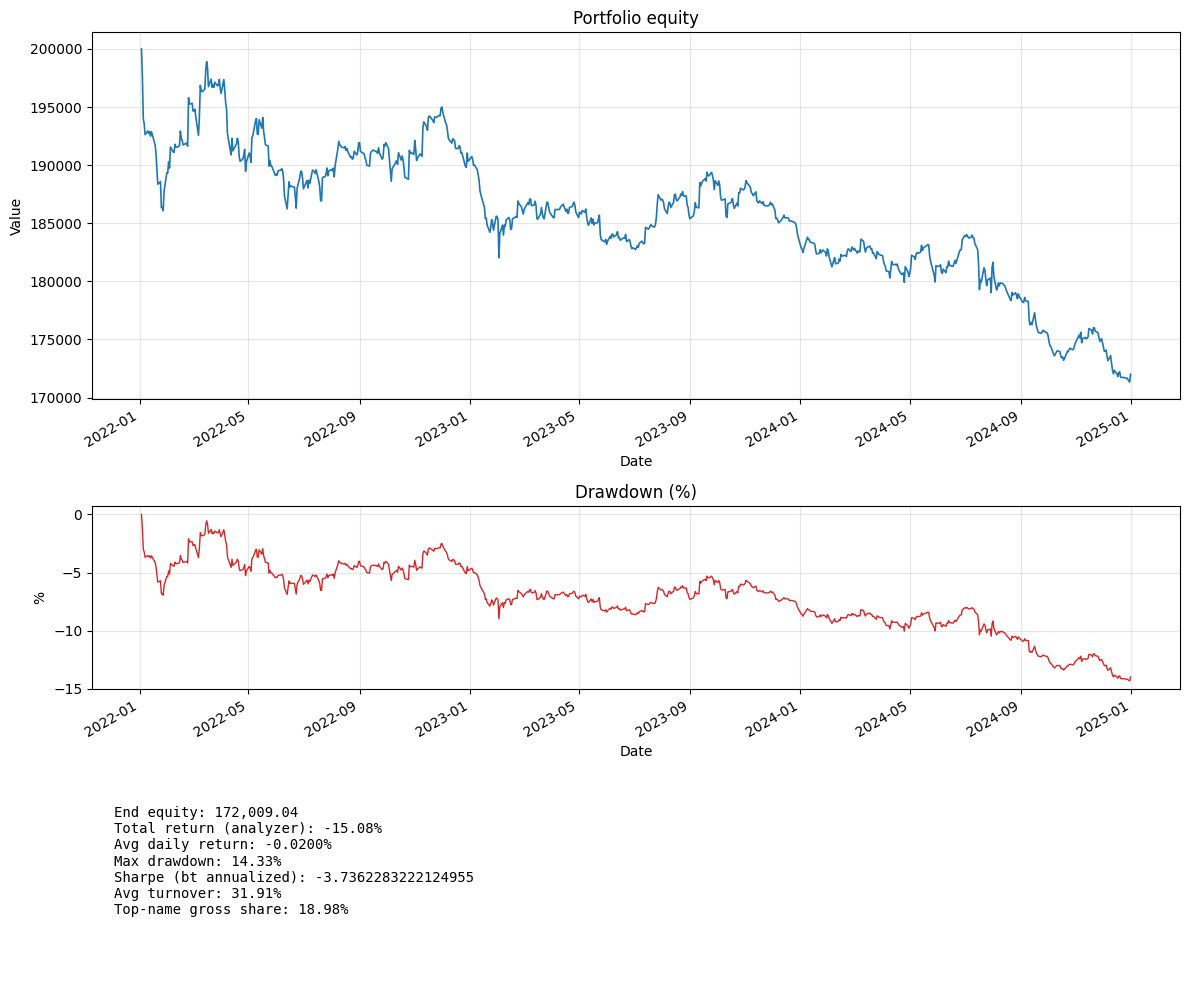

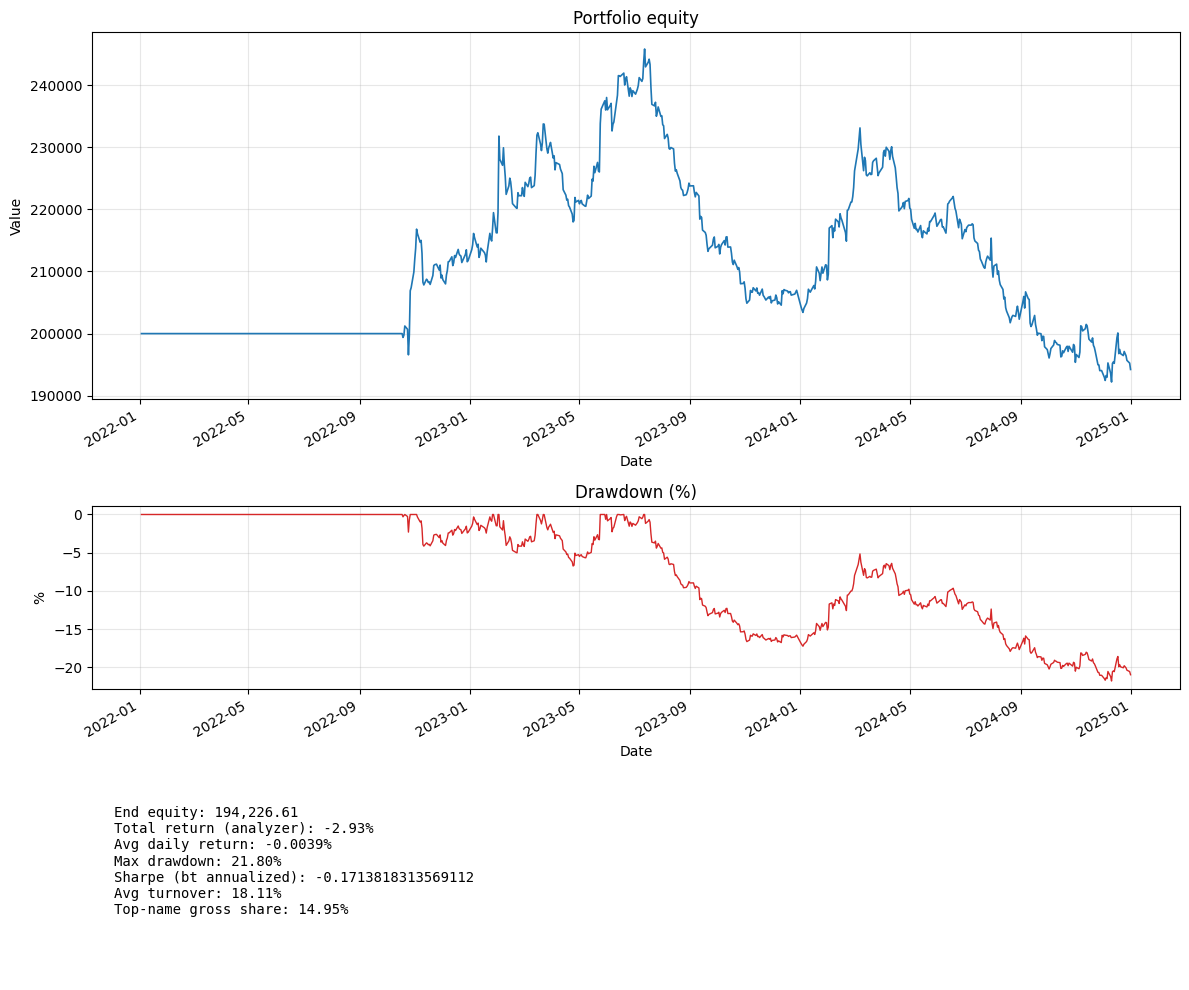

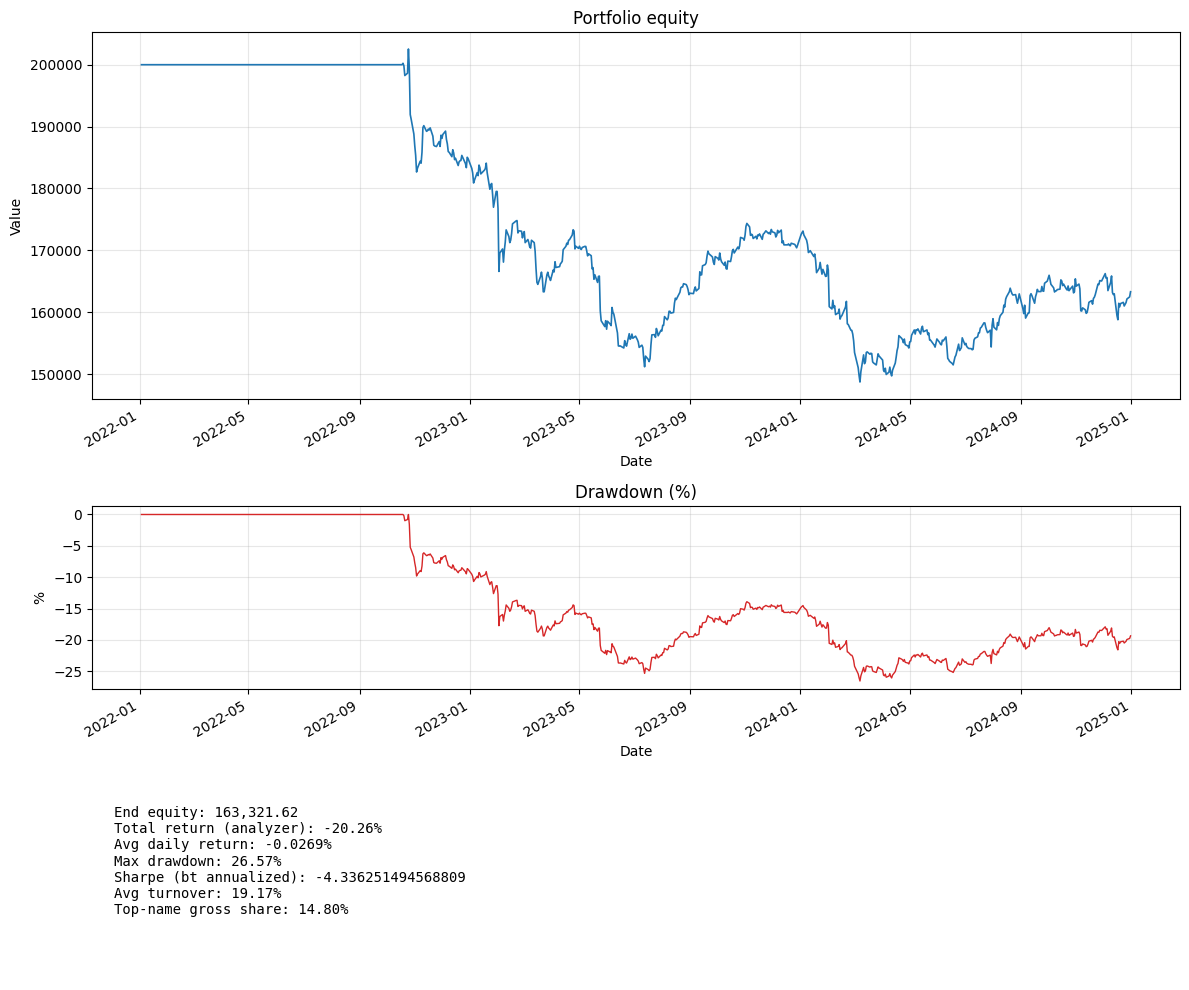

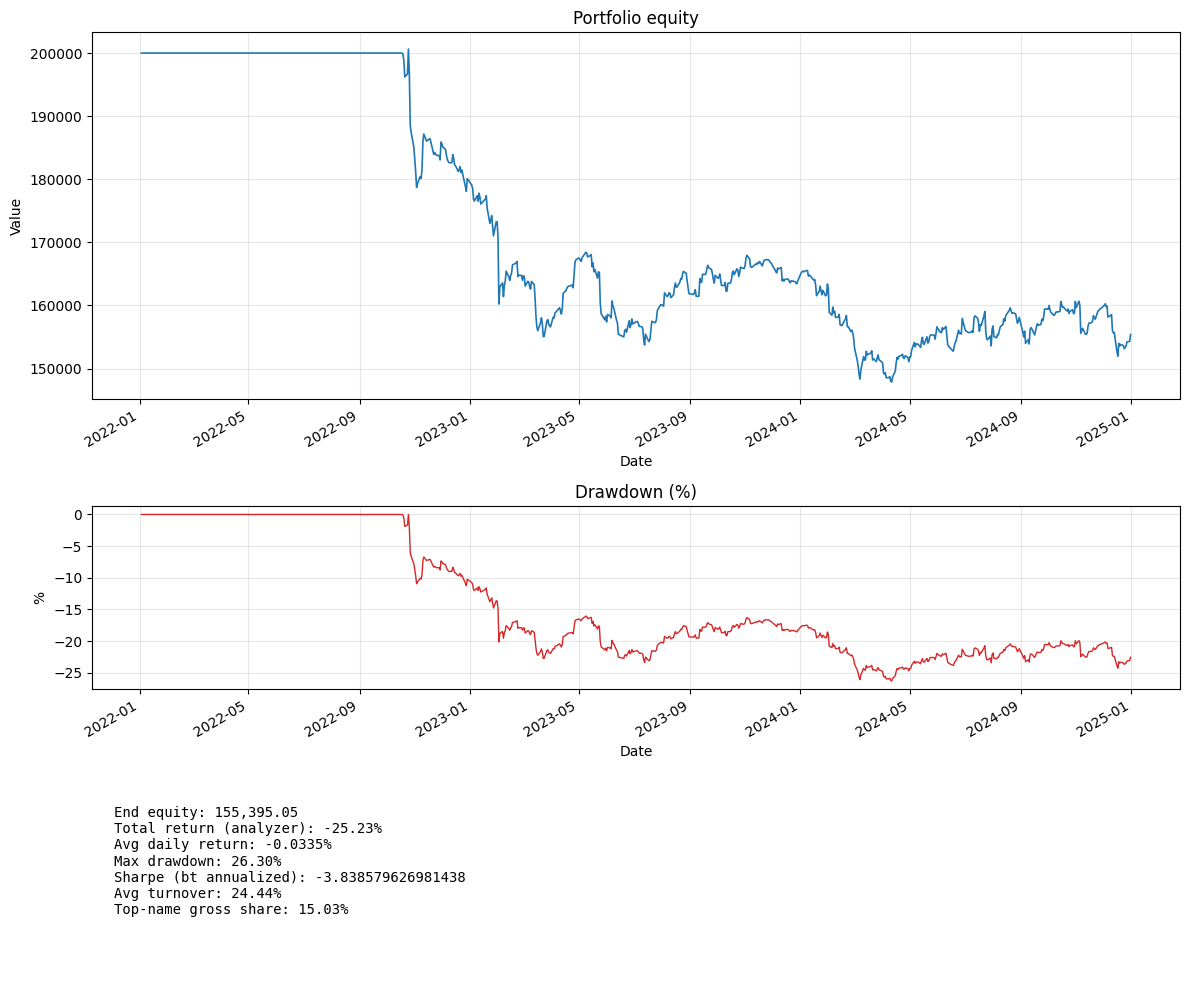

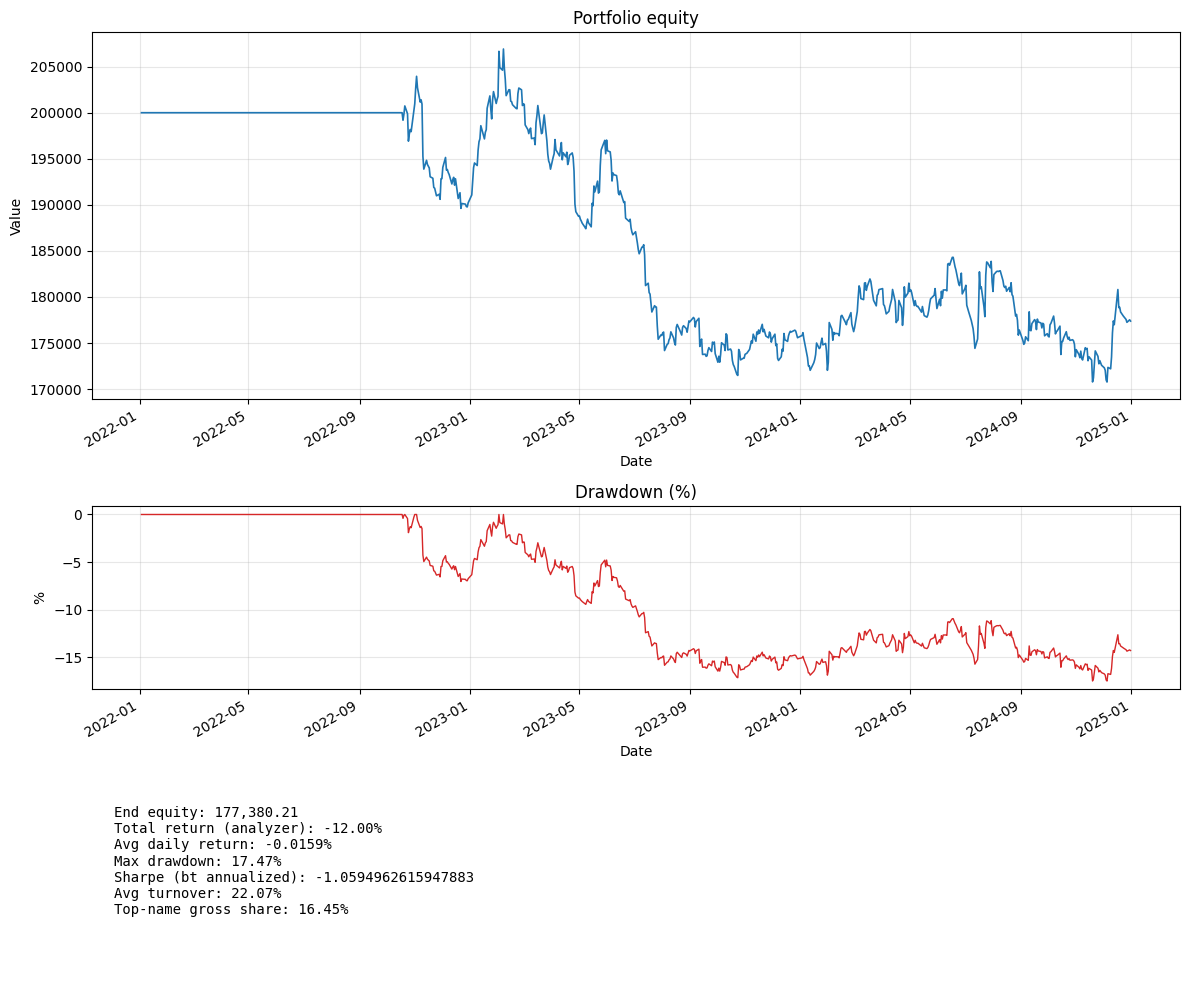

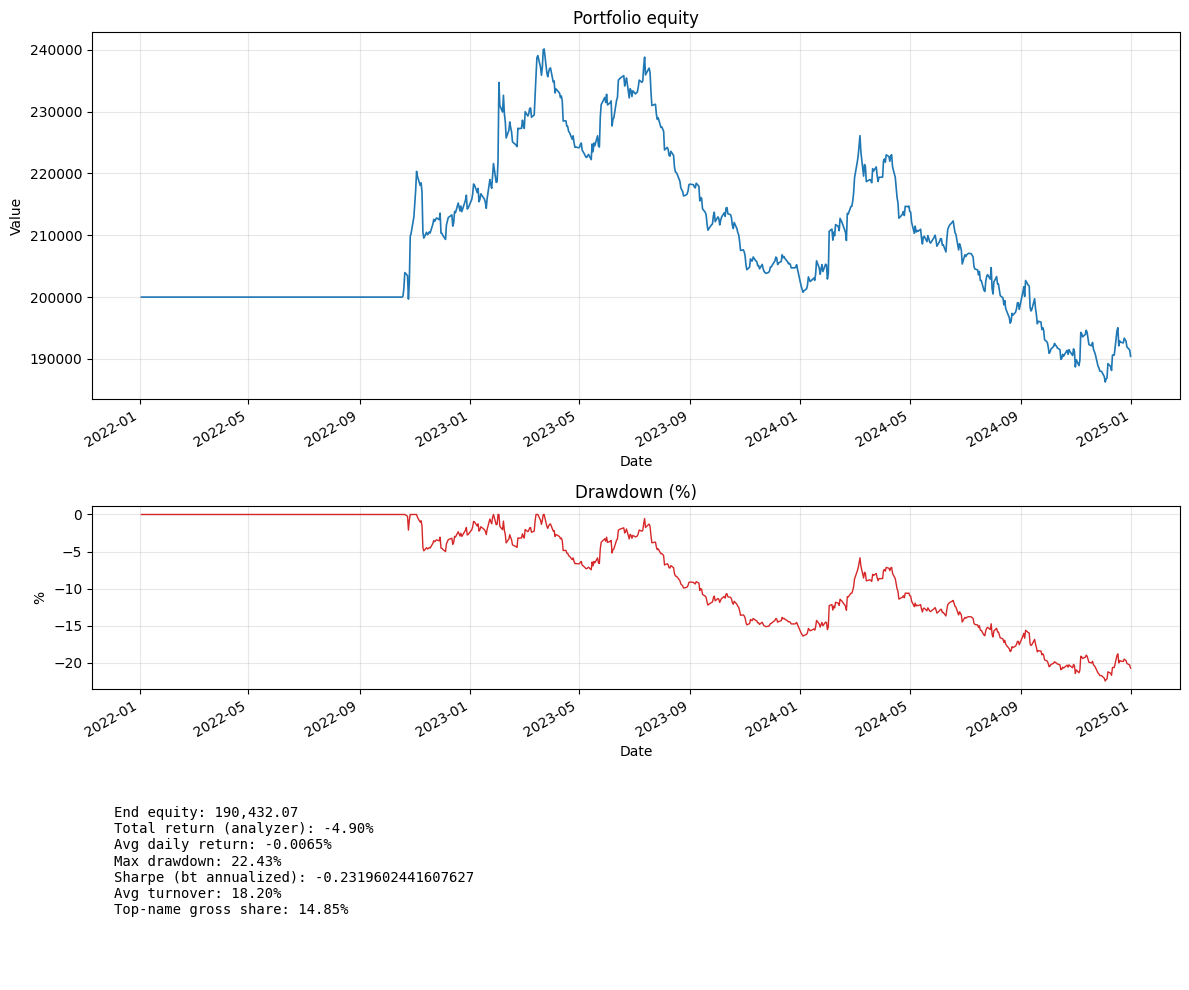

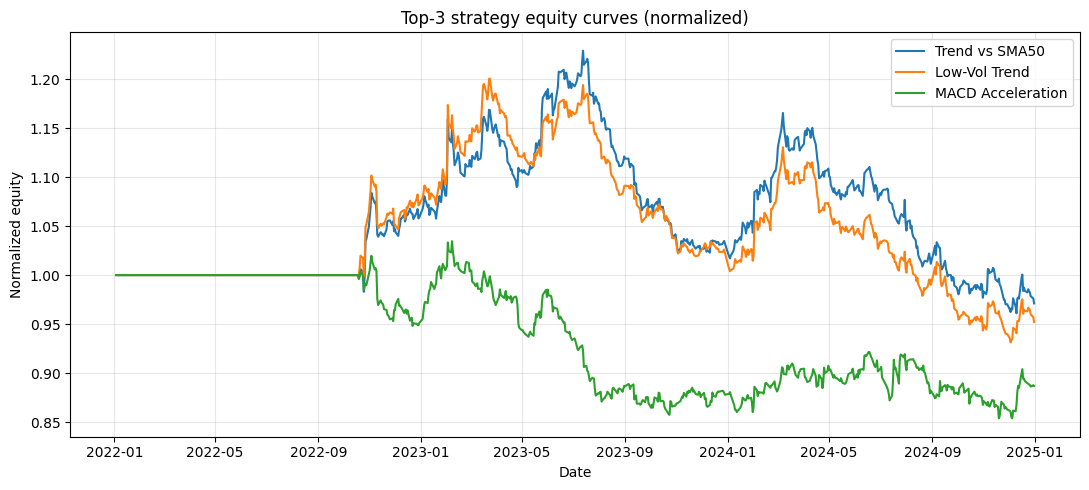

In [19]:
runs = [run_backtest(cfg) for cfg in STRATEGIES]

leaderboard = pd.DataFrame(
    [
        {
            "strategy": r["name"],
            "end_value": r["end_value"],
            "total_return_pct": r["total_return_pct"],
            "max_drawdown_pct": r["max_drawdown_pct"],
            "sharpe_ratio": r["sharpe_ratio"],
            "avg_turnover_pct": r["avg_turnover_pct"],
            "smoke_as_of": r["smoke"]["as_of"],
            "smoke_n_names": r["smoke"]["n_names"],
            "smoke_score_std": r["smoke"]["score_std"],
        }
        for r in runs
    ]
).sort_values(["total_return_pct", "sharpe_ratio"], ascending=False)

print("Leaderboard (best first):")
leaderboard.reset_index(drop=True)


# Compare equity curves for top 3
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))
for row in leaderboard.head(3).itertuples(index=False):
    run = next(r for r in runs if r["name"] == row.strategy)
    eq = run["result"]["equity_curve"]["Equity"]
    eq_norm = eq / eq.iloc[0]
    ax.plot(eq_norm.index, eq_norm.values, label=row.strategy)

ax.set_title("Top-3 strategy equity curves (normalized)")
ax.set_ylabel("Normalized equity")
ax.set_xlabel("Date")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

Best strategy: Trend vs SMA50


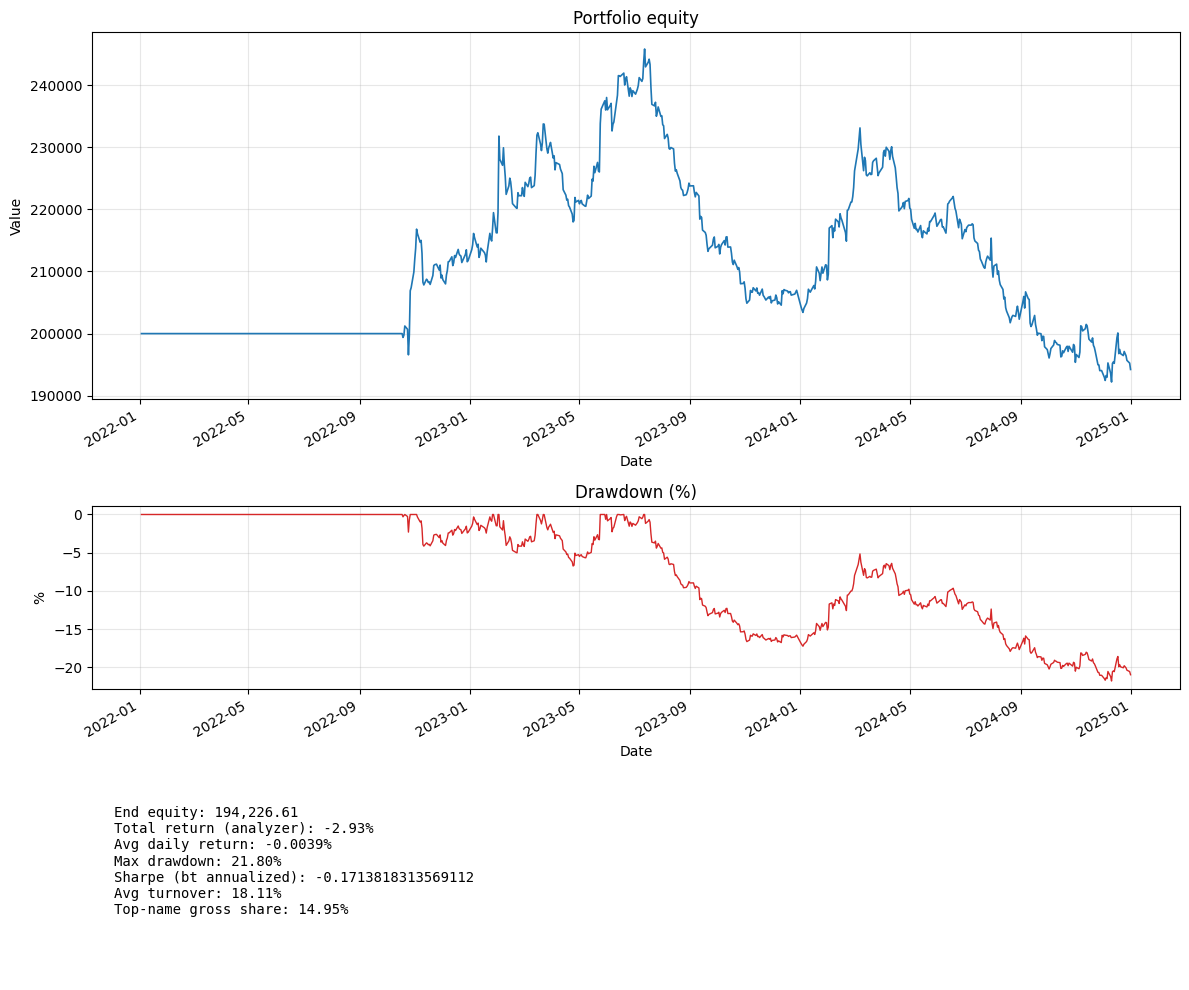

{'start_value': 200000.0,
 'end_value': 194226.60916903155,
 'total_return_pct': -2.929180066912433,
 'avg_daily_return_pct': -0.0038900133690736157,
 'max_drawdown_pct': 21.80416047981093,
 'max_drawdown_len': 370,
 'sharpe_ratio': -0.1713818313569112,
 'avg_turnover_pct': 18.109840053589362,
 'max_turnover_pct': 35.000007784171274,
 'rebalance_count': 553,
 'top_name_gross_share_pct': 14.953286755667271,
 'max_group_gross_share_pct': 32.54673146988247,
 'max_group_net_share_pct': 19.396492229700474}

In [20]:
best_name = leaderboard.iloc[0]["strategy"]
best_run = next(r for r in runs if r["name"] == best_name)

print("Best strategy:", best_name)
_ = best_run["bt"].results(show=True)
best_run["result"]["metrics"]

In [24]:
def make_mock_trading_client() -> MagicMock:
    client = MagicMock()

    clock = MagicMock()
    clock.is_open = True
    client.get_clock.return_value = clock

    acct = MagicMock()
    acct.buying_power = "500000"
    client.get_account.return_value = acct

    client.get_all_positions.return_value = []

    asset = MagicMock()
    asset.tradable = True
    asset.fractionable = True
    asset.shortable = True
    client.get_asset.return_value = asset

    return client


best_strat = best_run["strategy"]
mock_client = make_mock_trading_client()
trade = FinTrade(best_strat, trading_client=mock_client, paper=True)

last_date = pd.Timestamp(data.df.index.get_level_values("Date").max()).normalize()
decision = DecisionContext(as_of=last_date, data_source="yfinance_research")

report = trade.run(
    150_000.0,
    data,
    decision=decision,
    dry_run=True,
    cap_to_buying_power=False,
    min_order_notional=25.0,
    sector_gross_cap_fraction=0.35,
    group_net_cap_fraction=0.20,
    turnover_budget_fraction=0.35,
    adv_participation_fraction=0.10,
    constraints_mode="rescale",
)

exec_summary = {
    "correlation_id": report.correlation_id,
    "as_of": report.as_of,
    "n_targets": len(report.targets_usd),
    "n_order_attempts": len(report.order_attempts),
    "effective_gross": report.tradecapital_effective_gross,
    "warnings": report.warnings,
}

exec_summary

{'correlation_id': 'e61f09d432c74231a4dc9ddcfe94e526',
 'as_of': Timestamp('2024-12-31 00:00:00'),
 'n_targets': 12,
 'n_order_attempts': 12,
 'effective_gross': 52499.998632812494,
 'warnings': ["data_source=yfinance_research: Yahoo history may not match Alpaca fills — use AlpacaHistoricalMarketDataProvider + DecisionContext(data_source='alpaca_bars') for tighter parity.",
  'turnover_budget_applied observed=150000.00 limit=52500.00, mode=rescale']}

In [25]:
orders_df = pd.DataFrame(
    [
        {
            "symbol": a.symbol,
            "side": a.side,
            "notional": a.notional,
            "success": a.success,
            "status": a.final_status,
        }
        for a in report.order_attempts
    ]
).sort_values("notional", ascending=False)

orders_df.head(20)

,symbol,side,notional,success,status
3,GOOGL,buy,7681.72,True,dry_run
8,UNH,sell,7681.07,True,dry_run
0,AAPL,buy,6686.19,True,dry_run
11,ORCL,sell,6683.97,True,dry_run
7,XOM,sell,5202.88,True,dry_run
4,AMZN,buy,5200.40,True,dry_run
6,JPM,buy,3714.04,True,dry_run
2,NVDA,sell,3710.29,True,dry_run
10,KO,sell,2231.20,True,dry_run
5,META,buy,2229.17,True,dry_run


## Long-only (“buy side” / no short stock)

Cross-sectional **ranks are in `[0, 1]`**, so if we set **`neutralization="none"`** and use a **nonnegative** alpha, `FinStrat.pass_` scales to **gross = capital with only nonnegative dollar targets** (no short legs). Rebalancing **still places sell orders** when trimming a name’s weight; the portfolio remains **long-only** (no negative target notionals).

Long-only target sign check:
  Long-only equal weight: OK — no negative targets in sampled dates.
  Long-only trend (rank Dist_SMA50): OK — no negative targets in sampled dates.

Long-only backtest summary:
                         strategy     end_value  total_return_pct  max_drawdown_pct  sharpe_ratio  avg_turnover_pct
           Long-only equal weight 337003.845917         52.177698         26.332923      0.757523          0.899475
Long-only trend (rank Dist_SMA50) 431078.290498         76.797236         13.527930      1.778850         10.765838


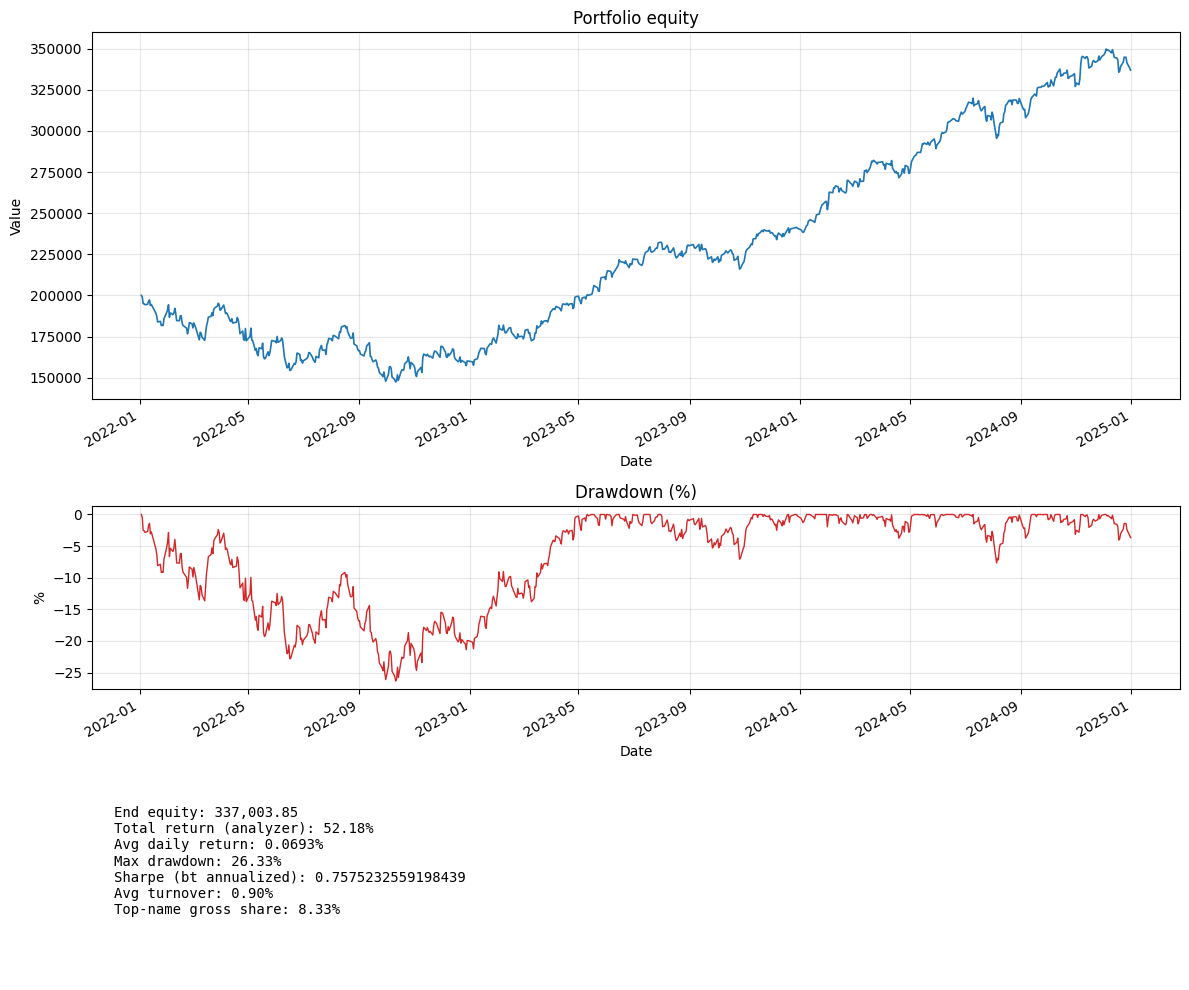

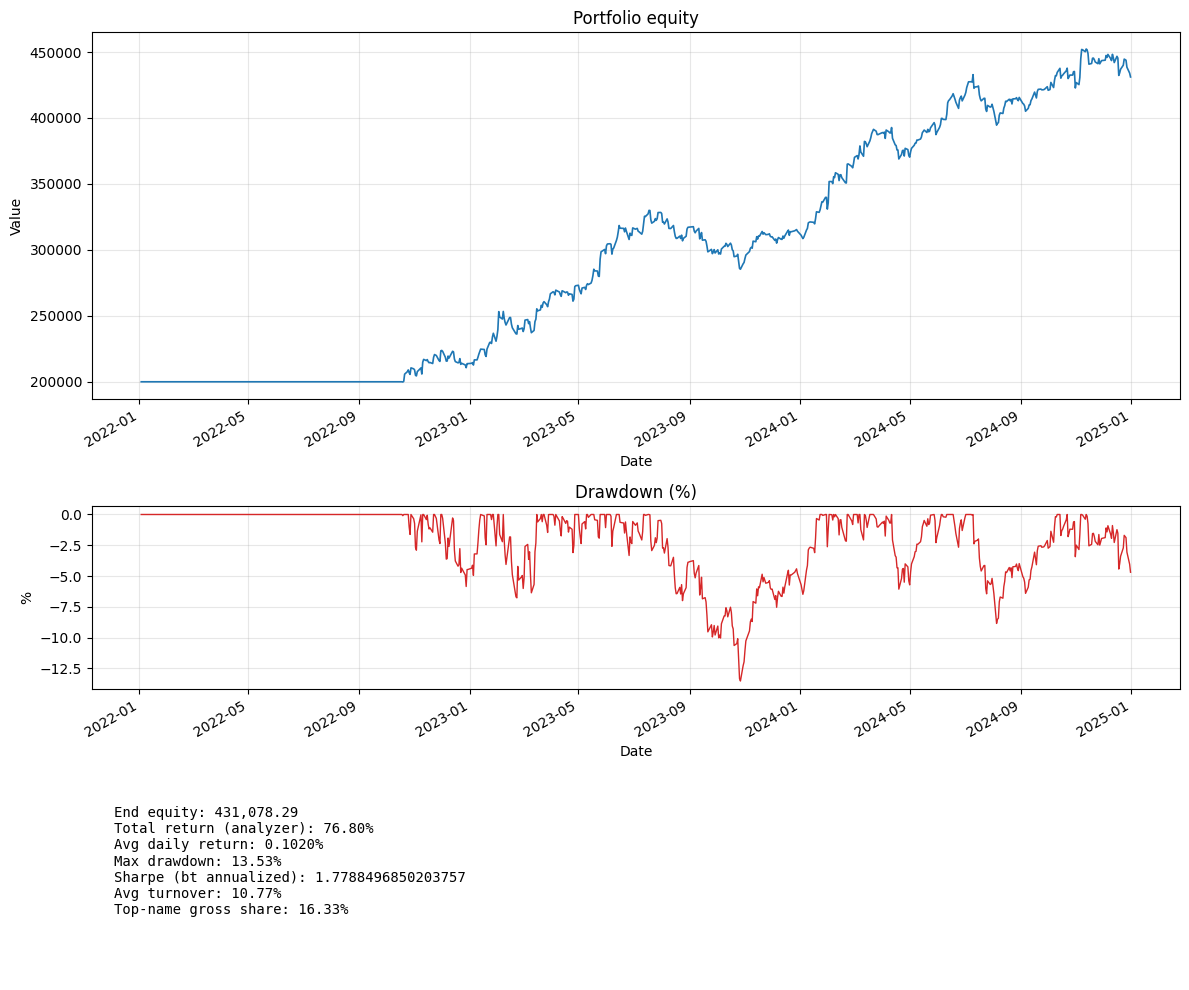

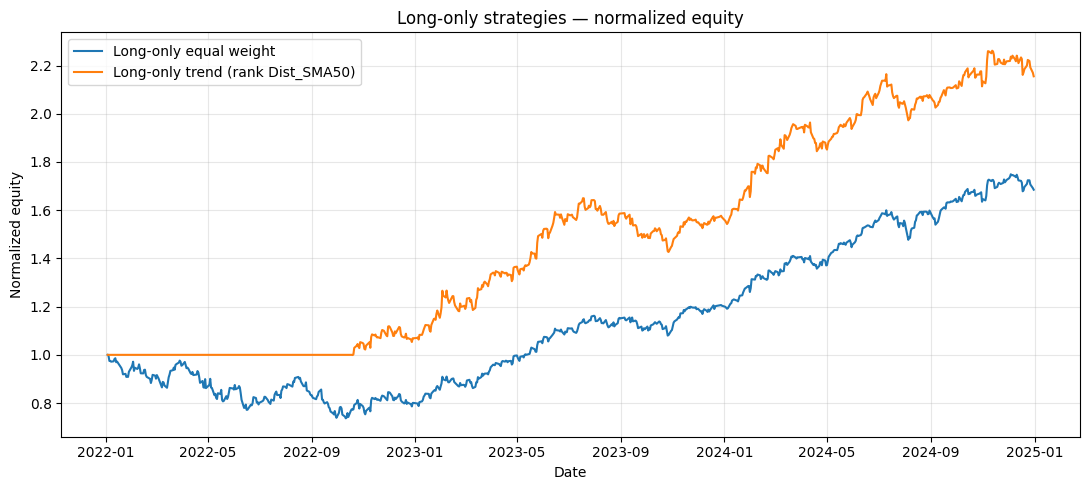

Long-only FinTrade dry-run: all targets ≥ 0 12 order rows


In [26]:
# Long-only strategies: no market demean → all weights stay on the buy/long side.
# Depends on: `data`, `ind`, `FinStrat`, `FinBT`, `FinTrade`, `DecisionContext`, `alpha_trend_vs_sma50`, `jnp`, `np`, `pd`.

from unittest.mock import MagicMock


def alpha_equal_long(panel: jnp.ndarray) -> jnp.ndarray:
    return jnp.ones(panel.shape[0], dtype=jnp.float32)


LONG_ONLY_STRATEGIES = [
    {
        "name": "Long-only equal weight",
        "alpha": alpha_equal_long,
        "decay": 0.0,
        "truncation": 0.0,
        "panel_columns": ind.STRATEGY_PANEL_OHLCV_ONLY,
        "jit_algorithm": False,
    },
    {
        "name": "Long-only trend (rank Dist_SMA50)",
        "alpha": alpha_trend_vs_sma50,
        "decay": 0.15,
        "truncation": 0.02,
        "panel_columns": None,
        "jit_algorithm": True,
    },
]


def build_long_only_strat(cfg: dict) -> FinStrat:
    return FinStrat(
        data,
        cfg["alpha"],
        decay=cfg["decay"],
        neutralization="none",
        truncation=cfg["truncation"],
        max_single_weight=0.25,
        jit_algorithm=bool(cfg.get("jit_algorithm", False)),
        panel_columns=cfg["panel_columns"],
    )


def assert_targets_long_only(strat: FinStrat, label: str) -> None:
    dates = data.df.index.get_level_values("Date").unique().sort_values()
    bad = 0
    for dt in reversed(dates[-750:]):
        try:
            panel, names = strat.panel_at(dt, live=True)
        except ValueError:
            continue
        if len(names) < 3:
            continue
        w = np.asarray(strat.pass_(panel, 100_000.0, tickers=names), dtype=float)
        if np.nanmin(w) < -1e-6:
            bad += 1
            print(f"  {label}: negative target on {dt} min={np.nanmin(w):.4f}")
    if bad == 0:
        print(f"  {label}: OK — no negative targets in sampled dates.")


def run_long_only_backtest(cfg: dict) -> dict:
    strat = build_long_only_strat(cfg)
    bt = FinBT(
        strat,
        data,
        cash=200_000.0,
        commission=0.0005,
        slippage_pct=0.0005,
        sector_gross_cap_fraction=0.60,
        group_net_cap_fraction=None,
        turnover_budget_fraction=0.50,
        adv_participation_fraction=0.15,
        constraints_mode="rescale",
    )
    bt.run(stdstats=False)
    result = bt.results(show=False)
    m = result["metrics"]
    return {
        "name": cfg["name"],
        "strategy": strat,
        "bt": bt,
        "result": result,
        "end_value": float(m["end_value"]),
        "total_return_pct": float(m["total_return_pct"]),
        "max_drawdown_pct": float(m["max_drawdown_pct"]),
        "sharpe_ratio": m["sharpe_ratio"],
        "avg_turnover_pct": float(m["avg_turnover_pct"]),
    }


print("Long-only target sign check:")
for cfg in LONG_ONLY_STRATEGIES:
    assert_targets_long_only(build_long_only_strat(cfg), cfg["name"])

long_runs = [run_long_only_backtest(cfg) for cfg in LONG_ONLY_STRATEGIES]

long_board = pd.DataFrame(
    [
        {
            "strategy": r["name"],
            "end_value": r["end_value"],
            "total_return_pct": r["total_return_pct"],
            "max_drawdown_pct": r["max_drawdown_pct"],
            "sharpe_ratio": r["sharpe_ratio"],
            "avg_turnover_pct": r["avg_turnover_pct"],
        }
        for r in long_runs
    ]
)

print("\nLong-only backtest summary:")
print(long_board.to_string(index=False))

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))
for r in long_runs:
    eq = r["result"]["equity_curve"]["Equity"]
    ax.plot(eq.index, eq / eq.iloc[0], label=r["name"])

ax.set_title("Long-only strategies — normalized equity")
ax.set_ylabel("Normalized equity")
ax.set_xlabel("Date")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Dry-run execution path on the trend long-only sleeve (from flat book → mostly buys first bar)

long_pick = next(r for r in long_runs if "trend" in r["name"].lower())


def _mock_trading_client_long() -> MagicMock:
    client = MagicMock()
    clock = MagicMock()
    clock.is_open = True
    client.get_clock.return_value = clock
    acct = MagicMock()
    acct.buying_power = "500000"
    client.get_account.return_value = acct
    client.get_all_positions.return_value = []
    asset = MagicMock()
    asset.tradable = True
    asset.fractionable = True
    asset.shortable = True
    client.get_asset.return_value = asset
    return client


ft_long = FinTrade(long_pick["strategy"], trading_client=_mock_trading_client_long(), paper=True)
last_date = pd.Timestamp(data.df.index.get_level_values("Date").max()).normalize()
rep_long = ft_long.run(
    150_000.0,
    data,
    decision=DecisionContext(as_of=last_date, data_source="yfinance_research"),
    dry_run=True,
    cap_to_buying_power=False,
    sector_gross_cap_fraction=0.60,
    turnover_budget_fraction=0.50,
    adv_participation_fraction=0.15,
    constraints_mode="rescale",
)
neg_targets = {k: v for k, v in rep_long.targets_usd.items() if v < -1e-6}
print("Long-only FinTrade dry-run:", "negative targets" if neg_targets else "all targets ≥ 0", len(rep_long.order_attempts), "order rows")